# Lab 12: Autoencoders and Variational Autoencoders


## Autoencoders (AE) (Part 1) - Lab Session

**Learning Goals:**
- Understand what AutoEncoder are and how they are derived off of PCA.
- Implement a simple AE in PyTorch
- Train a AE and visualize the results
- Explore the latent space and generate new images


##  Checkpoint 1: What is PCA?

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRdHqAFkauxsoutbKN6B3HNodN83V4lsh_7JA&s" width="400">


#### Key Features of PCA

1. **Unsupervised Learning**:
PCA does not require labels. It analyzes how the data varies and identifies the directions (principal components) with the most variance.

2. **Linear Compression**:
PCA performs linear dimensionality reduction by projecting data onto orthogonal vectors that capture maximum variance.

3. **Variance Maximization / Reconstruction Minimization**:
PCA can be viewed in two equivalent ways:

It finds directions that maximize variance.

It finds the projection that minimizes reconstruction error among all linear projections.

**Why is this important?**:
1. **Curse of Dimensionality**
PCA Lowers the dimensions, making datapoints similar to each other.
2. **Reduces Overfit**:
PCA stops us from seeing noisy dimensions, in which we can overfit to model.


<h3>Fisher’s Iris Dataset — Quick Overview</h3>

<p>
  The <strong>Iris dataset</strong> is a small, classic dataset introduced by Ronald Fisher in 1936.
  It contains <strong>150 samples</strong> of iris flowers from <strong>3 species</strong>:
  Setosa, Versicolor, and Virginica.
</p>

<h4>Features</h4>
<p>
  Each flower is described by four measurements:
</p>
<ul>
  <li>Sepal length</li>
  <li>Sepal width</li>
  <li>Petal length</li>
  <li>Petal width</li>
</ul>

<h4>Why It Works Well for PCA</h4>
<p>
  Because the dataset has <strong>4 numeric features</strong> and <strong>3 natural groups</strong>,
  it is ideal for demonstrating <strong>dimensionality reduction</strong>.
  PCA can compress the 4-dimensional data into <strong>2 principal components</strong> while still
  preserving most of the structure. In this reduced 2D space:
</p>

<ul>
  <li>The three iris species form distinct clusters.</li>
  <li>Setosa separates clearly, while Versicolor and Virginica partially overlap.</li>
</ul>

<p>
  This makes the Iris dataset one of the most common examples for visualizing how
  <strong>PCA reveals structure</strong> in high-dimensional data.
</p>


### Setup required Libraries

In [ ]:
# Install required packages (run once)
!pip install torch torchvision matplotlib numpy tqdm --quiet

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris  # just for a small example dataset

# 1. Load data (Iris: 150 samples, 4 features)
X_np, y = load_iris(return_X_y=True)  # X_np: (150, 4)
X = torch.tensor(X_np, dtype=torch.float32)  # to torch tensor

# 2. Center the data (subtract mean)
X_mean = X.mean(dim=0, keepdim=True)  # (1, 4)
X_centered = X - X_mean  # (150, 4)

# 3. Compute covariance matrix: (d x d)
n_samples = X_centered.shape[0]
cov = (X_centered.T @ X_centered) / (n_samples - 1)  # (4, 4)

# 4. Eigen-decomposition of covariance
eigvals, eigvecs = torch.linalg.eigh(cov)  # eigvecs: columns are eigenvectors

# 5. Sort eigenvectors by eigenvalue (descending)
idx = torch.argsort(eigvals, descending=True)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]  # (4, 4) sorted

# 6. Take top 2 principal components
W = NotImplementedError()  # (4, 2) #TODO

# 7. Project data to 2D
X_pca = X_centered @ W  # (150, 2)

print("Explained variance per PC:", eigvals[:4] / eigvals.sum())
print("Total variance kept:", float(eigvals[:2].sum() / eigvals.sum()))  # first 2 PCAs

# 8. Plot
X_pca_np = X_pca.detach().numpy()

plt.figure(figsize=(5, 4))
scatter = plt.scatter(X_pca_np[:, 0], X_pca_np[:, 1], c=y, cmap="viridis", s=20)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Iris dataset projected to 2D with PCA (PyTorch)")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()


##  Checkpoint 2: What are AutoEncoders (AEs)

<img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/1*qFzKC1GqOR17XaiQBex83w.png" width="600">


#### Key Features of AutoEncoders
- **Unsupervised Learning**: They do not require labeled data since they aim to reconstruct the input itself.

- **Compression**: AEs learn to reduce the dimensionality of data, making them useful for tasks like data compression and feature extraction. This replaces the classic PCA approach.

- **Reconstruction Loss**: The training objective is to minimize the difference between the input and reconstructed output, typically using a loss function like Mean Squared Error (MSE).


#### Objective Formulation of AutoEncoders

An Autoencoder consists of two main components:

1. **Encoder Function** ($f$): Maps the input data to a lower-dimensional latent space
2. **Decoder Function** ($g$): Reconstructs the original data from the latent representation


<h3>Why PCA Is Related to Autoencoders</h3>

<p>
  PCA and autoencoders are related because they both perform
  <strong>dimensionality reduction</strong>: they compress data into a smaller space while
  keeping the most important structure.
</p>

<h4>PCA as a Linear Autoencoder</h4>
<p>
  If you build an autoencoder using only <strong>linear layers</strong> and train it to
  reconstruct its input, it learns the <strong>same subspace</strong> as PCA.  
  In this sense:
</p>

<ul>
  <li><strong>PCA</strong> = best linear projection that keeps maximum variance</li>
  <li><strong>Linear AE</strong> = best linear reconstruction of the input</li>
</ul>

<p>
  These two objectives turn out to be equivalent.
</p>

<h4>Autoencoders Extend PCA</h4>
<p>
  When an autoencoder uses <strong>non-linear activations</strong>, it can learn
  complex, curved structures that PCA cannot.  
  So, autoencoders are essentially a <strong>non-linear generalization of PCA</strong>.
</p>


<h2>Denoising AutoEncoder (DAE) — Quick Overview</h2>

<p>
  A <strong>Denoising AutoEncoder (DAE)</strong> is a type of autoencoder trained to remove noise from corrupted data.
  It learns to map a <strong>noisy input</strong> back to a <strong>clean version</strong> of the same data.
</p>

<h3>Core Idea</h3>
<p>
  Instead of training the autoencoder to simply copy its input, we first <strong>corrupt</strong> the input
  (for example, by adding random noise), but we keep the <strong>target</strong> as the original clean data.
</p>

<pre>
clean image → (add noise) → noisy image → Encoder → Decoder → reconstructed clean image
</pre>

<p>
  The model must learn to <strong>ignore the noise</strong> and recover the underlying structure.
</p>

<h3>Why It Works</h3>
<ul>
  <li>Noise is random, but structure (digits, edges, shapes) is consistent.</li>
  <li>The encoder learns features that are <strong>robust</strong> to noise.</li>
  <li>The decoder learns to reconstruct the clean image from these robust features.</li>
</ul>

<h3>Training Objective</h3>
<p>
  The loss compares the output of the network to the <strong>clean</strong> image, not to the noisy one:
</p>

<pre>
Loss = MSE( denoised_output, clean_image )
</pre>

<p>
  The network is rewarded for:
</p>
<ul>
  <li>Removing noise</li>
  <li>Preserving details</li>
  <li>Reconstructing the original content</li>
</ul>

<h3>Benefits</h3>
<ul>
  <li>Produces <strong>cleaner latent representations</strong> than a plain autoencoder.</li>
  <li>Trains quickly, even on small datasets.</li>
  <li>Gives intuitive, visual before/after results.</li>
</ul>


### Data loading and preprocessing

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

### Load MNIST Dataset

We'll use MNIST (handwritten digits) because:
- Simple 28×28 grayscale images
- Fast to train
- Easy to visualize results

In [ ]:
# Data preprocessing: convert to tensors and normalize to [0, 1]
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

# Download and load training data
train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

# Create data loader
batch_size = 128
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=0
)

print(f"Dataset size: {len(train_dataset)}")
print(f"Number of batches: {len(train_loader)}")

In [ ]:
# Visualize some examples
examples = next(iter(train_loader))[0][:16]

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(examples[i].squeeze(), cmap="gray")
    ax.axis("off")
plt.suptitle("Sample MNIST Digits")
plt.tight_layout()
plt.show()

### Denoising AutoEncoder (DAE) Implementation

In [ ]:
class DenoiseAE(nn.Module):
    """
    Denoising AutoEncoder (AE)

    Input : (batch_size, 1, 28, 28)  noisy grayscale image
    Output: (batch_size, 1, 28, 28)  reconstructed (denoised) image
    """

    def __init__(self):
        super().__init__()

        # Encoder: 1x28x28 -> 64x7x7
        self.enc = nn.Sequential(
            None,  # TODO: Conv2d -> 32x28x28 (hint: in=1, out=32, kernel=3, padding=1)
            None,  # TODO: ReLU
            None,  # TODO: MaxPool2d -> 32x14x14 (hint: kernel=2, stride=2)
            None,  # TODO: Conv2d -> 64x14x14 (hint: in=32, out=64, kernel=3, padding=1)
            None,  # TODO: ReLU
            None,  # TODO: MaxPool2d -> 64x7x7
        )

        # Decoder: 64x7x7 -> 1x28x28
        self.dec = nn.Sequential(
            None,  # TODO: ConvTranspose2d -> 32x14x14 (hint: in=64, out=32, kernel=2, stride=2)
            None,  # TODO: ReLU
            None,  # TODO: ConvTranspose2d -> 1x28x28 (hint: in=32, out=1, kernel=2, stride=2)
            None,  # TODO: Sigmoid (output pixels in [0,1])
        )

    def forward(self, x):
        z = self.enc(x)  # latent feature map
        x_hat = self.dec(z)  # reconstruction
        return x_hat

In [ ]:
# Select device (GPU if available, else CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
# Create model and move it to device
model = DenoiseAE().to(device)
# Optimizer (Adam) with a slightly smaller learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# Reconstruction loss for the autoencoder
criterion = NotImplementedError()


In [ ]:
def add_noise(x, noise_level=0.4):
    # Add Gaussian noise scaled by noise_level
    noise = torch.randn_like(x) * noise_level
    # Keep pixel values in [0, 1]
    return torch.clamp(x + noise, 0.0, 1.0)


In [ ]:
from tqdm.auto import tqdm

num_epochs = 5

for epoch in range(num_epochs):
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

    for imgs, _ in pbar:
        imgs = imgs.to(device)
        noisy = add_noise(imgs)  # noisy input

        optimizer.zero_grad()
        outputs = model(noisy)  # denoised reconstruction
        loss = criterion(outputs, imgs)  # compare to clean image
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    print(f"Epoch {epoch + 1}: loss={epoch_loss / len(train_loader):.4f}")


In [ ]:
import matplotlib.pyplot as plt

model.eval()
imgs, _ = next(iter(train_loader))  # one batch
imgs = imgs.to(device)
noisy = add_noise(imgs, noise_level=0.3)

with torch.no_grad():
    denoised = model(noisy)

# move to CPU for plotting
imgs = imgs.cpu()
noisy = noisy.cpu()
denoised = denoised.cpu()

n_show = 8  # number of examples to display
plt.figure(figsize=(9, 4))

for i in range(n_show):
    # Original
    plt.subplot(3, n_show, i + 1)
    plt.imshow(imgs[i, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # Noisy
    plt.subplot(3, n_show, n_show + i + 1)
    plt.imshow(noisy[i, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Noisy")

    # Denoised
    plt.subplot(3, n_show, 2 * n_show + i + 1)
    plt.imshow(denoised[i, 0], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Denoised")

plt.tight_layout()
plt.show()



#### Limitations of AutoEncoders
- **Limited Control Over the Latent Space Representation**
- **Overfitting**
- **Limitations in Generation**

#### How to overcome these limitations ?
- Enter Variational Autoencoders

# Variational Autoencoders (VAE) (Part 2) - Lab Session

**Learning Goals:**
- Understand what VAEs are and how they differ from regular autoencoders
- Implement a simple VAE in PyTorch
- Train a VAE and visualize the results
- Explore the latent space and generate new images


##  Checkpoint 3: What are Variational Autoencoders?

### Quick Recap: Regular Autoencoders
- **Encoder**: Compresses input → latent representation (bottleneck)
- **Decoder**: Reconstructs input from latent representation
- **Goal**: Learn to reconstruct the input data

### The VAE Difference
Instead of encoding to a **single point** in latent space, VAEs encode to a **probability distribution**:
- Encoder outputs: **mean (μ)** and **variance (σ²)** of a distribution
- Sample from this distribution to get the latent representation
- This allows **generating new data** by sampling from the learned distribution!
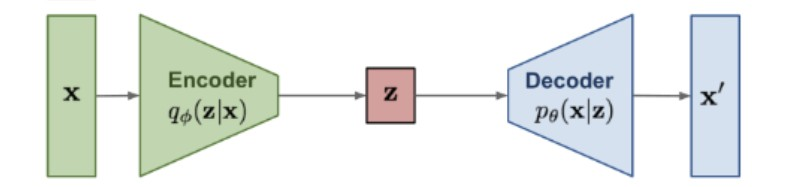
### Why is this useful?
1. **Generative modeling**: Create new, realistic data samples
2. **Smooth latent space**: Similar inputs produce similar latent codes
3. **Uncertainty**: The model can express uncertainty in its encodings

**Discussion Question:** Why might a probabilistic latent space be better than a deterministic one for generating new images?

---
## Part 1 - A: Building an MLP-based VAE

### Checkpoint 4: Architecture Overview

A VAE has three main components:

1. **Encoder**: Input -> mu and log(sigma^2)
2. **Reparameterization**: Sample z = mu + sigma * epsilon (where epsilon ~ N(0,1))
3. **Decoder**: z -> Reconstructed output

**Discussion Question:** Why do we predict log(sigma^2) instead of sigma directly?

In [ ]:
class VAE(nn.Module):
    """Simple Variational Autoencoder for MNIST"""

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        """
        Args:
            input_dim: Size of flattened input (28*28 = 784 for MNIST)
            hidden_dim: Size of hidden layers
            latent_dim: Size of latent space (the bottleneck)
        """
        super(VAE, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # ============ ENCODER ============
        # Maps input to hidden representation
        self.fc1 = None  # TODO: nn.Linear(input_dim -> hidden_dim)

        # Output mean (mu) of the latent distribution
        self.fc_mu = None  # TODO: nn.Linear(hidden_dim -> latent_dim)

        # Output log-variance log(sigma^2) of the latent distribution
        self.fc_logvar = None  # TODO: nn.Linear(hidden_dim -> latent_dim)

        # ============ DECODER ============
        # Maps latent space back to hidden representation
        self.fc3 = None  # TODO: nn.Linear(latent_dim -> hidden_dim)

        # Maps hidden representation back to input space
        self.fc4 = None  # TODO: nn.Linear(hidden_dim -> input_dim)

    def encode(self, x):
        """
        Encoder: Input -> mu and log(sigma^2)

        Args:
            x: Input images [batch_size, 784]
        Returns:
            mu: Mean of latent distribution [batch_size, latent_dim]
            logvar: Log-variance of latent distribution [batch_size, latent_dim]
        """
        h = None  # TODO: pass x through fc1 and apply ReLU
        mu = None  # TODO: pass h through fc_mu
        logvar = None  # TODO: pass h through fc_logvar
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = mu + sigma * epsilon, where epsilon ~ N(0,1)

        This allows backpropagation through the sampling operation!

        Args:
            mu: Mean [batch_size, latent_dim]
            logvar: Log-variance [batch_size, latent_dim]
        Returns:
            z: Sampled latent vector [batch_size, latent_dim]
        """
        std = None  # TODO: compute std from logvar (hint: std = exp(0.5 * logvar))
        eps = None  # TODO: sample epsilon from N(0,1) with same shape as std (hint: torch.randn_like)
        z = None  # TODO: z = mu + std * eps
        return z

    def decode(self, z):
        """
        Decoder: Latent vector -> Reconstructed output

        Args:
            z: Latent vector [batch_size, latent_dim]
        Returns:
            reconstruction: Reconstructed images [batch_size, 784]
        """
        h = None  # TODO: pass z through fc3 and apply ReLU
        recon = None  # TODO: pass h through fc4 and apply Sigmoid
        return recon

    def forward(self, x):
        """
        Complete forward pass: encode -> reparameterize -> decode

        Args:
            x: Input images [batch_size, 1, 28, 28]
        Returns:
            recon_x: Reconstructed images [batch_size, 784]
            mu: Mean of latent distribution
            logvar: Log-variance of latent distribution
        """
        # Flatten the input
        x = x.view(-1, self.input_dim)

        # Encode
        mu, logvar = self.encode(x)

        # Sample from the latent distribution
        z = self.reparameterize(mu, logvar)

        # Decode
        recon_x = self.decode(z)

        return recon_x, mu, logvar

In [ ]:
# Create the model
model = VAE(input_dim=784, hidden_dim=400, latent_dim=20)
model = model.to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

---
## Part 1 - B: Convolutional VAE (ConvVAE)

The MLP-based VAE flattens the image and loses spatial structure. A convolutional VAE preserves 2D structure using Conv2d/ConvTranspose2d layers, which leads to better reconstructions.

**Key differences from MLP VAE:**
- Encoder uses Conv2d + BatchNorm + ReLU + stride-2 downsampling
- Decoder uses ConvTranspose2d to upsample back to image size
- mu and logvar are still produced by linear layers from the flattened conv features

In [ ]:
class ConvVAE(nn.Module):
    """Convolutional VAE for MNIST"""

    def __init__(self, latent_dim=20):
        super(ConvVAE, self).__init__()
        self.latent_dim = latent_dim

        # ============ ENCODER ============
        # Input: (batch, 1, 28, 28)
        self.encoder_conv = nn.Sequential(
            None,  # TODO: Conv2d(1, 32, kernel_size=3, stride=2, padding=1)  -> (batch, 32, 14, 14)
            None,  # TODO: BatchNorm2d(32)
            None,  # TODO: ReLU
            None,  # TODO: Conv2d(32, 64, kernel_size=3, stride=2, padding=1) -> (batch, 64, 7, 7)
            None,  # TODO: BatchNorm2d(64)
            None,  # TODO: ReLU
        )
        # After conv: (batch, 64, 7, 7) = (batch, 3136)
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # ============ DECODER ============
        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            None,  # TODO: ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1) -> (batch, 32, 14, 14)
            None,  # TODO: BatchNorm2d(32)
            None,  # TODO: ReLU
            None,  # TODO: ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1) -> (batch, 1, 28, 28)
            None,  # TODO: Sigmoid
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)  # flatten
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        h = F.relu(self.fc_decode(z))
        h = h.view(-1, 64, 7, 7)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon.view(-1, 784), mu, logvar

In [ ]:
# Uncomment the line below to use ConvVAE instead of MLP VAE for training:
# model = ConvVAE(latent_dim=20).to(device)
# print(model)
# print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

---
## Part 2: The VAE Loss Function

### Checkpoint 5: Understanding the Loss

VAE loss = **Reconstruction Loss** + **beta * KL Divergence**

1. **Reconstruction Loss**: How well can we reconstruct the input?
   - Binary Cross-Entropy (BCE) for pixel-wise comparison
   - Lower = better reconstruction

2. **KL Divergence**: How close is our learned distribution to standard normal N(0,1)?
   - Regularizes the latent space
   - Ensures we can sample from N(0,1) to generate new data
   - Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)

3. **Beta weighting (beta-VAE)**: Controls the tradeoff between reconstruction and regularization.
   - beta < 1: prioritize reconstruction quality
   - beta = 1: standard VAE
   - beta > 1: prioritize disentangled/smooth latent space, at the cost of blurrier reconstructions

**Discussion Question:** What would happen if we only used reconstruction loss? What if we only used KL divergence?

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    Calculate VAE loss: Reconstruction + beta * KL Divergence

    Parameters
    ----------
    recon_x
        Reconstructed images [batch_size, 784]
    x
        Original images [batch_size, 784]
    mu
        Mean of latent distribution [batch_size, latent_dim]
    logvar
        Log-variance of latent distribution [batch_size, latent_dim]
    beta
        Weight on the KL divergence term (default=1.0 for standard VAE)

    Returns
    -------
    total_loss
        Combined loss value
    recon_loss
        Reconstruction loss component
    kl_loss
        KL divergence component
    """
    # Reconstruction loss: Binary Cross-Entropy
    # Measures how well we can reconstruct the input
    recon_loss = (
        None  # TODO: F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    )

    # KL Divergence: KL(N(mu, sigma^2) || N(0, 1))
    # Regularizes the latent space to be close to standard normal
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = None  # TODO: -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total loss with beta weighting
    total_loss = None  # TODO: recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

---
## Part 3: Training the VAE

In [ ]:
def train_epoch(model, train_loader, optimizer, device, beta=1.0):
    """
    Train the VAE for one epoch

    Returns:
        avg_loss: Average total loss
        avg_recon: Average reconstruction loss
        avg_kl: Average KL divergence
    """
    model.train()
    total_loss = 0
    total_recon = 0
    total_kl = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar, beta=beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    return avg_loss, avg_recon, avg_kl

In [ ]:
# Training configuration
num_epochs = 10
learning_rate = 1e-3
beta = 1.0  # Change this to experiment with beta-VAE (try 0.1, 1.0, 5.0, 10.0)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"Starting training with beta={beta}...\n")
history = {"loss": [], "recon": [], "kl": []}

for epoch in range(1, num_epochs + 1):
    avg_loss, avg_recon, avg_kl = train_epoch(
        model, train_loader, optimizer, device, beta=beta
    )

    history["loss"].append(avg_loss)
    history["recon"].append(avg_recon)
    history["kl"].append(avg_kl)

    print(
        f"Epoch {epoch:2d}/{num_epochs} | "
        f"Loss: {avg_loss:.4f} | "
        f"Recon: {avg_recon:.4f} | "
        f"KL: {avg_kl:.4f}"
    )

print("\nTraining complete!")

In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["loss"])
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(history["recon"], color="orange")
axes[1].set_title("Reconstruction Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

axes[2].plot(history["kl"], color="green")
axes[2].set_title("KL Divergence")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(True)

plt.tight_layout()
plt.show()

---
## Part 4: Visualizing Results

### Checkpoint 6: Reconstruction Quality

In [ ]:
def visualize_reconstruction(model, data_loader, device, n_images=10):
    """
    Visualize original vs reconstructed images
    """
    model.eval()

    # Get a batch of data
    data, _ = next(iter(data_loader))
    data = data[:n_images].to(device)

    # Reconstruct
    with torch.no_grad():
        recon, _, _ = model(data)

    # Move to CPU for plotting
    data = data.cpu()
    recon = recon.view(-1, 1, 28, 28).cpu()

    # Plot
    fig, axes = plt.subplots(2, n_images, figsize=(n_images * 1.5, 3))

    for i in range(n_images):
        # Original
        axes[0, i].imshow(data[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=10)

        # Reconstruction
        axes[1, i].imshow(recon[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed", fontsize=10)

    plt.tight_layout()
    plt.show()


# Visualize reconstructions
visualize_reconstruction(model, train_loader, device)

### Generating New Images

The key capability of VAEs: sample random points from N(0,1) and decode them to generate new images.

In [ ]:
def generate_images(model, device, n_images=16):
    """
    Generate new images by sampling from the latent space
    """
    model.eval()

    with torch.no_grad():
        # Sample random points from standard normal
        z = torch.randn(n_images, model.latent_dim).to(device)

        # Decode to generate images
        generated = model.decode(z)
        generated = generated.view(-1, 1, 28, 28).cpu()

    # Plot
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].squeeze(), cmap="gray")
        ax.axis("off")

    plt.suptitle("Generated Digits (sampled from N(0,1))")
    plt.tight_layout()
    plt.show()


# Generate new images
generate_images(model, device)

**Discussion Question:** How do the generated images compare to real MNIST digits? What could we do to improve quality?

---
## Part 5: Quantitative Evaluation

Visual inspection alone is insufficient. We compute MSE and Structural Similarity (SSIM) between originals and reconstructions to get a numerical measure of quality.

In [ ]:
def compute_ssim_batch(img1, img2):
    """
    Compute mean SSIM between two batches of single-channel images.
    Simplified SSIM using statistics over each image.
    """
    # img1, img2: (batch, 1, 28, 28)
    C1 = 0.01**2
    C2 = 0.03**2

    mu1 = img1.mean(dim=[2, 3], keepdim=True)
    mu2 = img2.mean(dim=[2, 3], keepdim=True)

    sigma1_sq = ((img1 - mu1) ** 2).mean(dim=[2, 3], keepdim=True)
    sigma2_sq = ((img2 - mu2) ** 2).mean(dim=[2, 3], keepdim=True)
    sigma12 = ((img1 - mu1) * (img2 - mu2)).mean(dim=[2, 3], keepdim=True)

    ssim_map = ((2 * mu1 * mu2 + C1) * (2 * sigma12 + C2)) / (
        (mu1**2 + mu2**2 + C1) * (sigma1_sq + sigma2_sq + C2)
    )
    return ssim_map.mean().item()


def evaluate_reconstruction(model, data_loader, device, n_batches=10):
    """Compute MSE and SSIM over n_batches of data."""
    model.eval()
    total_mse = 0.0
    total_ssim = 0.0
    count = 0

    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            if i >= n_batches:
                break
            data = data.to(device)
            recon, _, _ = model(data)
            recon = recon.view_as(data)

            mse = F.mse_loss(recon, data, reduction="sum").item()
            ssim_val = compute_ssim_batch(data, recon)

            total_mse += mse
            total_ssim += ssim_val
            count += 1

    avg_mse = total_mse / (count * data.size(0))
    avg_ssim = total_ssim / count
    print(f"Average MSE:  {avg_mse:.6f}")
    print(f"Average SSIM: {avg_ssim:.4f}  (1.0 = perfect)")
    return avg_mse, avg_ssim


evaluate_reconstruction(model, train_loader, device)

---
## Part 6: Exploring the Latent Space

### Checkpoint 7: Latent Space Interpolation

One of the most important properties of VAEs: smooth transitions between images in latent space.

In [ ]:
def interpolate_latent_space(model, data_loader, device, n_steps=10):
    """
    Interpolate between two random images in latent space.
    Works for both MLP VAE (expects flattened input) and ConvVAE (expects image tensors).
    """
    model.eval()

    data, _ = next(iter(data_loader))
    # Randomly select two different images
    idx = torch.randperm(data.size(0))[:2]
    img1 = data[idx[0] : idx[0] + 1].to(device)
    img2 = data[idx[1] : idx[1] + 1].to(device)

    # Conv encoders expect [B, C, H, W], MLP encoders expect [B, 784].
    use_conv_input = hasattr(model, "encoder_conv")
    enc_in1 = img1 if use_conv_input else img1.view(img1.size(0), -1)
    enc_in2 = img2 if use_conv_input else img2.view(img2.size(0), -1)

    with torch.no_grad():
        mu1, _ = model.encode(enc_in1)
        mu2, _ = model.encode(enc_in2)

        interpolations = []
        for alpha in np.linspace(0, 1, n_steps):
            z = (1 - alpha) * mu1 + alpha * mu2
            decoded = model.decode(z)

            if decoded.dim() == 2:
                img = decoded.view(28, 28)
            elif decoded.dim() == 4:
                img = decoded[0, 0]
            else:
                img = decoded.squeeze()

            interpolations.append(img.cpu())

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.2, 1.5))
    for i, (ax, img) in enumerate(zip(axes, interpolations)):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title("Start", fontsize=8)
        elif i == n_steps - 1:
            ax.set_title("End", fontsize=8)

    plt.suptitle("Latent Space Interpolation")
    plt.tight_layout()
    plt.show()


# Try interpolation multiple times to see different digit transitions
print("Different interpolations between random digit pairs:\n")
for i in range(3):
    interpolate_latent_space(model, train_loader, device, n_steps=10)

**Discussion Question:** What does smooth interpolation tell us about the latent space? Why is this important?

---
## Part 7: Beta-VAE Experiment

### Checkpoint 8: Reconstruction vs. Regularization Tradeoff

The beta parameter controls how much weight the KL divergence gets relative to reconstruction loss. Sweeping beta reveals a fundamental tradeoff:
- **Low beta**: sharper reconstructions, but the latent space may have gaps and be hard to sample from
- **High beta**: smoother, more structured latent space, but blurrier reconstructions

Run the cell below to train multiple models with different beta values and compare.

In [ ]:
# Beta-VAE sweep experiment
beta_values = [0.1, 1.0, 5.0, 10.0]
beta_models = {}
beta_histories = {}

for b in beta_values:
    print(f"\n{'=' * 50}")
    print(f"Training with beta = {b}")
    print(f"{'=' * 50}")

    m = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    hist = {"loss": [], "recon": [], "kl": []}

    for epoch in range(1, 11):
        avg_loss, avg_recon, avg_kl = train_epoch(m, train_loader, opt, device, beta=b)
        hist["loss"].append(avg_loss)
        hist["recon"].append(avg_recon)
        hist["kl"].append(avg_kl)
        if epoch % 5 == 0:
            print(
                f"  Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}"
            )

    beta_models[b] = m
    beta_histories[b] = hist

In [ ]:
# Compare reconstructions across beta values
fig, axes = plt.subplots(
    len(beta_values) + 1, 8, figsize=(12, 2 * (len(beta_values) + 1))
)

data, _ = next(iter(train_loader))
data = data[:8].to(device)

# Row 0: originals
for j in range(8):
    axes[0, j].imshow(data[j].cpu().squeeze(), cmap="gray")
    axes[0, j].axis("off")
    if j == 0:
        axes[0, j].set_ylabel("Original", fontsize=10, rotation=0, labelpad=60)

# Rows 1+: reconstructions per beta
for i, b in enumerate(beta_values):
    m = beta_models[b]
    m.eval()
    with torch.no_grad():
        recon, _, _ = m(data)
        recon = recon.view(-1, 1, 28, 28).cpu()
    for j in range(8):
        axes[i + 1, j].imshow(recon[j].squeeze(), cmap="gray")
        axes[i + 1, j].axis("off")
        if j == 0:
            axes[i + 1, j].set_ylabel(f"beta={b}", fontsize=10, rotation=0, labelpad=60)

plt.suptitle("Reconstruction Quality vs. Beta", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Compare generation quality across beta values
fig, axes = plt.subplots(len(beta_values), 8, figsize=(12, 2 * len(beta_values)))

for i, b in enumerate(beta_values):
    m = beta_models[b]
    m.eval()
    with torch.no_grad():
        z = torch.randn(8, m.latent_dim).to(device)
        generated = m.decode(z).view(-1, 1, 28, 28).cpu()
    for j in range(8):
        axes[i, j].imshow(generated[j].squeeze(), cmap="gray")
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(f"beta={b}", fontsize=10, rotation=0, labelpad=60)

plt.suptitle("Generated Samples vs. Beta", fontsize=14)
plt.tight_layout()
plt.show()

**Discussion Question:** Which beta value gives the best reconstructions? Which gives the best generated samples? Why might these be different?

---
## Bonus Experiments

### Experiment 1: Visualize 2D Latent Space

To visualize the latent space directly, we retrain a VAE with `latent_dim=2`. This lets us plot every encoded digit on a 2D plane and see how the model organizes different classes.

In [ ]:
# Train a 2D VAE for visualization
model_2d = VAE(input_dim=784, hidden_dim=400, latent_dim=2).to(device)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=1e-3)

print("Training 2D VAE...")
for epoch in range(1, 21):
    avg_loss, avg_recon, avg_kl = train_epoch(
        model_2d, train_loader, optimizer_2d, device, beta=1.0
    )
    if epoch % 5 == 0:
        print(
            f"  Epoch {epoch:2d} | Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | KL: {avg_kl:.4f}"
        )
print("Done!")

In [ ]:
def visualize_latent_space_2d(model, data_loader, device):
    """Scatter plot of the 2D latent space, colored by digit class."""
    assert model.latent_dim == 2, "This visualization requires latent_dim=2"

    model.eval()
    latents = []
    labels = []

    with torch.no_grad():
        for data, label in data_loader:
            data = data.to(device)
            mu, _ = model.encode(data.view(-1, 784))
            latents.append(mu.cpu())
            labels.append(label)

    latents = torch.cat(latents).numpy()
    labels = torch.cat(labels).numpy()

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        latents[:, 0], latents[:, 1], c=labels, cmap="tab10", alpha=0.5, s=1
    )
    plt.colorbar(scatter)
    plt.title("2D Latent Space (colored by digit class)")
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.show()


visualize_latent_space_2d(model_2d, train_loader, device)

### Experiment 1 - B: Decoder Grid Traversal

Sample a uniform grid over the 2D latent space and decode each point. This produces the canonical VAE visualization: a mosaic showing how the decoder maps different regions of latent space to different digits.

In [ ]:
def plot_latent_grid(model, device, n=20, digit_size=28, z_range=3.0):
    """
    Decode a grid of points in 2D latent space to produce an image mosaic.

    Args:
        n: Number of grid points per axis
        z_range: Range of z values to sample (will use [-z_range, z_range])
    """
    assert model.latent_dim == 2, "Grid traversal requires latent_dim=2"
    model.eval()

    figure = np.zeros((digit_size * n, digit_size * n))
    grid_x = np.linspace(-z_range, z_range, n)
    grid_y = np.linspace(z_range, -z_range, n)  # flip so top = high y

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
                decoded = model.decode(z).cpu().numpy().reshape(digit_size, digit_size)
                figure[
                    i * digit_size : (i + 1) * digit_size,
                    j * digit_size : (j + 1) * digit_size,
                ] = decoded

    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap="gray")
    plt.title(f"Decoder Grid Traversal (z in [{-z_range}, {z_range}])")
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.axis("off")
    plt.show()


plot_latent_grid(model_2d, device, n=20, z_range=3.0)

---
### Experiment 2: Conditional VAE (CVAE)

A standard VAE has no control over which digit it generates. A Conditional VAE fixes this by feeding the class label (as a one-hot vector) to both the encoder and decoder. This lets us generate specific digits on demand.

**Architecture changes:**
- Encoder input: image (784) + one-hot label (10) = 794 dims
- Decoder input: z (latent_dim) + one-hot label (10) = latent_dim + 10 dims

In [ ]:
class CVAE(nn.Module):
    """Conditional VAE: condition on digit class label"""

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20, num_classes=10):
        super(CVAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        # Encoder: input + one-hot label -> hidden -> mu, logvar
        self.fc1 = None  # TODO: nn.Linear(input_dim + num_classes, hidden_dim)
        self.fc_mu = None  # TODO: nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = None  # TODO: nn.Linear(hidden_dim, latent_dim)

        # Decoder: z + one-hot label -> hidden -> reconstruction
        self.fc3 = None  # TODO: nn.Linear(latent_dim + num_classes, hidden_dim)
        self.fc4 = None  # TODO: nn.Linear(hidden_dim, input_dim)

    def encode(self, x, c):
        """
        Args:
            x: images [batch, 784]
            c: one-hot labels [batch, num_classes]
        """
        # TODO: concatenate x and c along dim=1, then fc1 + ReLU
        h = None
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z, c):
        """
        Args:
            z: latent vector [batch, latent_dim]
            c: one-hot labels [batch, num_classes]
        """
        # TODO: concatenate z and c along dim=1, then fc3 + ReLU, fc4 + Sigmoid
        recon = None
        return recon

    def forward(self, x, labels):
        c = F.one_hot(labels, self.num_classes).float()
        x_flat = x.view(-1, self.input_dim)
        mu, logvar = self.encode(x_flat, c)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, c)
        return recon, mu, logvar

In [ ]:
# Training loop for CVAE (uncomment after implementing the class above)

cvae = CVAE(latent_dim=20).to(device)
cvae_opt = optim.Adam(cvae.parameters(), lr=1e-3)

for epoch in range(1, 11):
    cvae.train()
    total_loss = 0
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        cvae_opt.zero_grad()
        recon, mu, logvar = cvae(data, labels)
        loss, _, _ = vae_loss(recon, data, mu, logvar)
        loss.backward()
        cvae_opt.step()
        total_loss += loss.item()
    if epoch % 5 == 0:
        print(
            f"CVAE Epoch {epoch} | Loss: {total_loss / len(train_loader.dataset):.4f}"
        )

# Generate specific digits
cvae.eval()
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for digit in range(10):
    c = F.one_hot(torch.tensor([digit]), 10).float().to(device)
    with torch.no_grad():
        for row in range(2):
            z = torch.randn(1, cvae.latent_dim).to(device)
            generated = cvae.decode(z, c).view(28, 28).cpu()
            axes[row, digit].imshow(generated, cmap="gray")
            axes[row, digit].axis("off")
            if row == 0:
                axes[row, digit].set_title(str(digit), fontsize=10)
plt.suptitle("CVAE: Generating Specific Digits")
plt.tight_layout()
plt.show()

---
## Summary and Key Takeaways

### What We Covered:

1. **Autoencoders**: PCA connection, denoising AE with Conv2d layers
2. **VAE Architecture**: Encoder -> mu and log(sigma^2), reparameterization trick, decoder
3. **VAE Loss**: Reconstruction loss + KL divergence, and how beta controls their tradeoff
4. **MLP vs. Conv VAE**: Why convolutional architectures preserve spatial structure better
5. **Quantitative Evaluation**: MSE and SSIM metrics beyond visual inspection
6. **Latent Space Exploration**: Interpolation, 2D scatter plots, decoder grid traversal
7. **Beta-VAE**: How varying beta trades off reconstruction quality vs. latent space structure
8. **Conditional VAE**: Controlling generation by conditioning on class labels

### References:
- Kingma & Welling (2014), "Auto-Encoding Variational Bayes": https://arxiv.org/abs/1312.6114
- Higgins et al. (2017), "beta-VAE": https://openreview.net/forum?id=Sy2fzU9gl
- Sohn et al. (2015), "Learning Structured Output Representation using Deep Conditional Generative Models" (CVAE): https://papers.nips.cc/paper/2015/hash/8d55a249e6baa5c06772297520da2051-Abstract.html
- PyTorch VAE implementations: https://github.com/AntixK/PyTorch-VAE